Note, in this example below I am correcting already corrected data, so it is not expected to look good, but you can tell if the correctio is similar to the correcection that is already applie by checkking Long 2010 Figure xy (forgot wich figure it was)

In [1]:
import atmPy.radiation.retrievals.broadband_shortwave_radiation as atmbsr
import atmPy.general.measurement_site as atmms

In [48]:
plt.rcParams['figure.dpi'] = 200

In [2]:
def convert_degree2radian(da):
    assert(da.units == 'degree'), 'nosososs'
    out = np.deg2rad(da)
    out.attrs['units'] = 'radian'
    return out

In [99]:
ds.close()

In [100]:
ds = xr.open_dataset('racoro.20090527.175738.cdf')

ds

ds = ds.rename({'aircraft_roll': 'platform_roll'})
ds['platform_roll'] = convert_degree2radian(ds.platform_roll)
ds.platform_roll.attrs['positive'] = 'right-side-down'

ds = ds.rename({'aircraft_pitch': 'platform_pitch'})
ds['platform_pitch'] = convert_degree2radian(ds.platform_pitch) 
ds.platform_pitch.attrs['positive'] = 'nose-up'

ds = ds.rename({'aircraft_head': 'platform_heading'})
ds['platform_heading'] = convert_degree2radian(ds.platform_heading)
ds = ds.rename({'zen_swflx_cm22': 'global_horizontal'})

ds = ds.rename({'dir_swflx_spn1': 'direct_horizontal'})

ds['direct_horizontal'] = ds.direct_horizontal.where(ds.direct_horizontal >-1000)
ds['global_horizontal'] = ds.global_horizontal.where(ds.global_horizontal >-1000)

ds = ds.rename({'lat': 'latitude', 'lon':'longitude'})
ds['longitude'] = - ds.longitude

ds = ds.rename({'gps_alt': 'altitude'})

ds['diffuse_horizontal'] = ds.global_horizontal - ds.direct_horizontal

ds = ds.rename({'time': 'datetime'})
dt = pd.to_datetime(ds.base_time.values) + pd.to_timedelta(ds.time_offset, unit='s')
ds = ds.assign_coords({'datetime':dt})

In [101]:
reload(atmbsr)
reload(atmbsr.tiltcorrection)
reload(atmbsr.atmgms)

<module 'atmPy.general.measurement_site' from '/Users/htelg/prog/atm-py/atmPy/general/measurement_site.py'>

In [102]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds)
self = rin

# rin.site.plot_path(extent_pad=4, zoom_level=4)
# rin.sun_position

In [103]:
out = rin.apply_tilt_correction()
out

bla


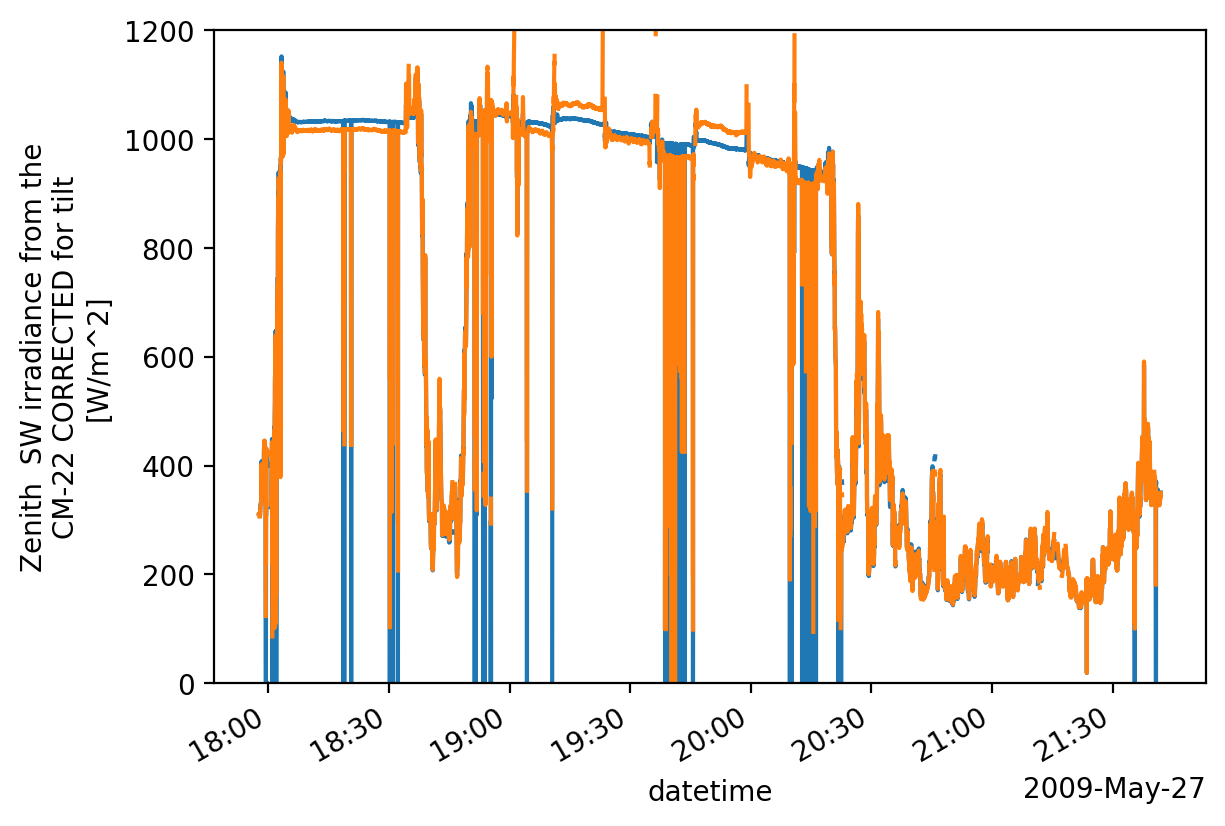

In [104]:
f,a = plt.subplots()
ds.global_horizontal.plot()
out.dataset.global_horizontal.plot(ax = a)
a.set_ylim(0, 1200)
f.autofmt_xdate()